# Medical Insurance Cost Prediction Using Regression Models

## Problem Definition
Predict individual medical insurance `charges` using age, sex, BMI, children, smoker status, and region.

This is a supervised **regression** problem because the target is continuous.


In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge, RidgeCV, LassoCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from xgboost import XGBRegressor

RANDOM_STATE = 42



## 1. Data Collection

In [2]:
DATA_PATH = "insurance.csv"
df = pd.read_csv(DATA_PATH)
df.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 2. Data Quality Checks

In [3]:
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())


Shape: (1338, 7)

Data types:
age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

Missing values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Duplicate rows: 1


In [4]:
df = df.drop_duplicates().copy()
print("Shape after duplicate removal:", df.shape)


Shape after duplicate removal: (1337, 7)


## 3. Exploratory Data Analysis

In [5]:
df.describe()


,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


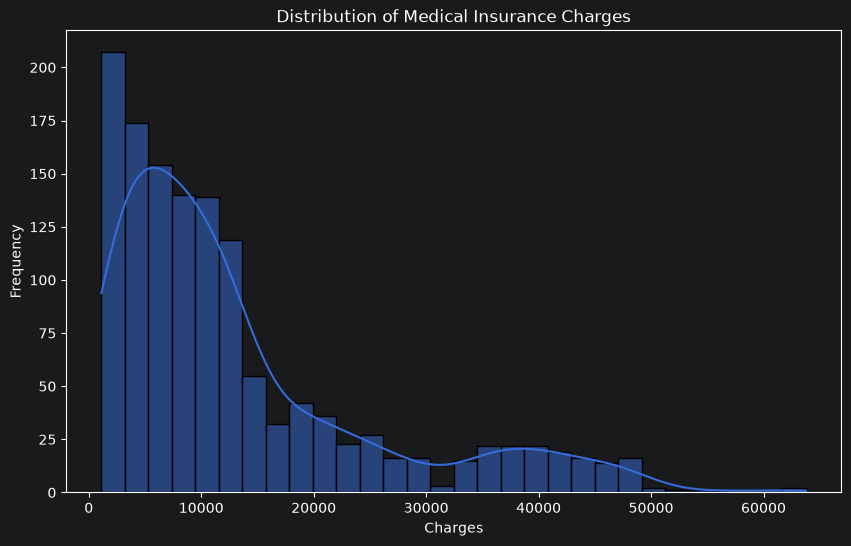

In [6]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x="charges", kde=True, bins=30)
plt.title("Distribution of Medical Insurance Charges")
plt.xlabel("Charges")
plt.ylabel("Frequency")
plt.show()


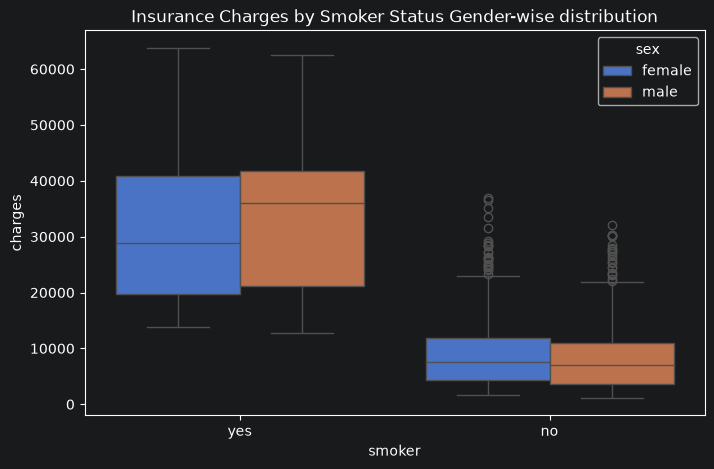

In [7]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="smoker", y="charges", hue="sex")
plt.title("Insurance Charges by Smoker Status Gender-wise distribution")
plt.show()


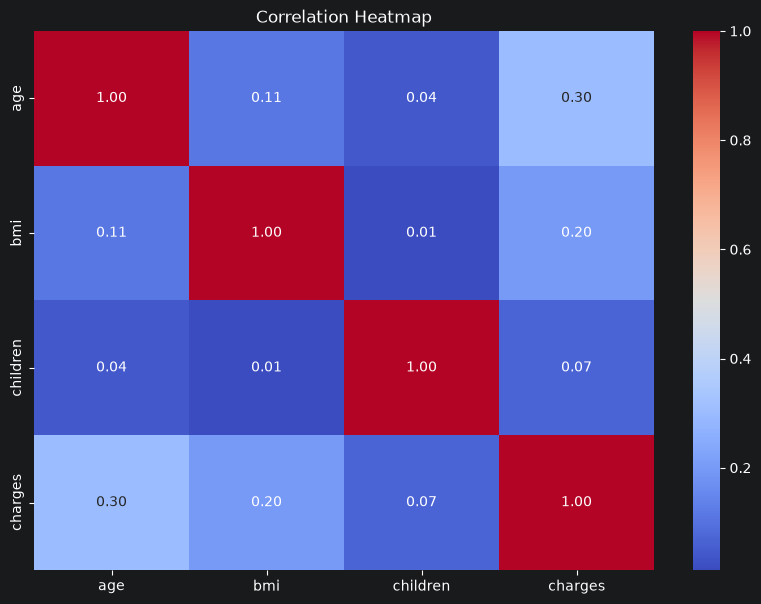

In [8]:
plt.figure(figsize=(10, 7))
sns.heatmap(
    df.select_dtypes(include=["number"]).corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()


## 4. Preprocessing

In [9]:
# ── Label Encoding: for binary categories ──
# since the `sex` and `smoker` columns have only (male or female) and (Yes or No) data, we will use Label encoding to replace the categorical values

le = LabelEncoder()
df["sex"] = le.fit_transform(df["sex"])
df["smoker"] = le.fit_transform(df["smoker"])

# One-Hot Encoding for region
df = pd.get_dummies(
    df,
    columns=["region"],
    prefix="region", dtype=int
)

df.head()



,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,0,0,0,1
1,18,1,33.770,1,0,1725.55230,0,0,1,0
2,28,1,33.000,3,0,4449.46200,0,0,1,0
3,33,1,22.705,0,0,21984.47061,0,1,0,0
4,32,1,28.880,0,0,3866.85520,0,1,0,0


## 5. Train/Test Split




In [10]:
TARGET = "charges"

X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE
)

print("Training rows:", len(X_train))
print("Total Training features: ", X_train.shape[1])
print("Testing rows:", len(X_test))

Training rows: 1002
Total Training features:  9
Testing rows: 335


### Scaling

In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

## 6. Model Training and Evaluation

In [16]:
results = []
# Models that uses the Scaled Data for training implementation
scaled_models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "RidgeCV Regression": RidgeCV(),
    "Lasso Regression": Lasso(),
    "LassoCV Regression": LassoCV(),
    "ElasticNet": ElasticNet()
}

for name, model in scaled_models.items():
    model.fit(X_train_scaled, y_train)
    predictions = model.predict(X_test_scaled)

    r2 = r2_score(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, predictions)

    results.append(
        {
            "Model": model,
            "Model_Name": name,
            "R2_Score": r2,
            "MSE": mse,
            "RMSE": rmse,
            "MAE": mae,
        }
    )

    print(f"Model: {name}")
    print(f"R2 Score : {r2:.4f}")
    print(f"MSE      : {mse:.2f}")
    print(f"RMSE     : {rmse:.2f}")
    print(f"MAE      : {mae:.2f}")
    print("-" * 40)


Model: Linear Regression
R2 Score : 0.7924
MSE      : 35899629.40
RMSE     : 5991.63
MAE      : 4000.03
----------------------------------------
Model: Ridge Regression
R2 Score : 0.7922
MSE      : 35930372.64
RMSE     : 5994.19
MAE      : 4002.09
----------------------------------------
Model: RidgeCV Regression
R2 Score : 0.7922
MSE      : 35930372.64
RMSE     : 5994.19
MAE      : 4002.09
----------------------------------------
Model: Lasso Regression
R2 Score : 0.7923
MSE      : 35907428.48
RMSE     : 5992.28
MAE      : 4000.18
----------------------------------------
Model: LassoCV Regression
R2 Score : 0.7906
MSE      : 36211855.19
RMSE     : 6017.63
MAE      : 4008.11
----------------------------------------
Model: ElasticNet
R2 Score : 0.6622
MSE      : 58401069.16
RMSE     : 7642.06
MAE      : 5285.00
----------------------------------------


In [17]:
# Tree-based models
tree_models = {
    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        max_depth=3,
        random_state=RANDOM_STATE
    ),

    "XGBoost": XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=RANDOM_STATE,
        objective="reg:squarederror"
    )
}

# Train tree models
for name, model in tree_models.items():

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    r2 = r2_score(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, predictions)

    results.append(
        {
            "Model": model,          # Actual trained model
            "Model_Name": name,      # Model name
            "R2_Score": r2,
            "MSE": mse,
            "RMSE": rmse,
            "MAE": mae,
        }
    )

    print(f"Model: {name}")
    print(f"R2 Score : {r2:.4f}")
    print(f"MSE      : {mse:.2f}")
    print(f"RMSE     : {rmse:.2f}")
    print(f"MAE      : {mae:.2f}")
    print("-" * 40)

Model: Random Forest
R2 Score : 0.8826
MSE      : 20304267.98
RMSE     : 4506.03
MAE      : 2700.27
----------------------------------------
Model: XGBoost
R2 Score : 0.8921
MSE      : 18663702.83
RMSE     : 4320.15
MAE      : 2498.54
----------------------------------------


In [18]:
# Model comparison
comparison = pd.DataFrame(results).sort_values(
    "R2_Score",
    ascending=False
)

comparison

,Model,Model_Name,R2_Score,MSE,RMSE,MAE
7,"XGBRegressor(base_score=None, booster=None, ca...",XGBoost,0.892061,1.866370e+07,4320.150787,2498.544889
6,"(DecisionTreeRegressor(max_depth=3, max_featur...",Random Forest,0.882573,2.030427e+07,4506.025741,2700.273774
0,LinearRegression(),Linear Regression,0.792379,3.589963e+07,5991.629945,4000.030624
3,Lasso(),Lasso Regression,0.792334,3.590743e+07,5992.280741,4000.177869
2,RidgeCV(),RidgeCV Regression,0.792202,3.593037e+07,5994.194912,4002.087398
1,Ridge(),Ridge Regression,0.792202,3.593037e+07,5994.194912,4002.087398
4,LassoCV(),LassoCV Regression,0.790574,3.621186e+07,6017.628702,4008.107421
5,ElasticNet(),ElasticNet,0.662245,5.840107e+07,7642.059223,5285.004792


## 7. Select and Save the Best Model

In [20]:
best_result = max(results, key=lambda item: item["R2_Score"])

best_model = best_result["Model"]
best_model_name = best_result["Model_Name"]

MODEL_PATH = "models/medical_insurance_best_model.pkl"

os.makedirs("models", exist_ok=True)

# joblib.dump(best_model, MODEL_PATH)

print("Best model:", best_model_name)
print(f"R2: {best_result['R2_Score']:.4f}")
print(f"RMSE: {best_result['RMSE']:.2f}")
print(f"MAE: {best_result['MAE']:.2f}")
joblib.dump(best_model, MODEL_PATH)
print("Saved:", MODEL_PATH)

Best model: XGBoost
R2: 0.8921
RMSE: 4320.15
MAE: 2498.54
Saved: models/medical_insurance_best_model.pkl


## 8. Conclusion

The best model is selected from the held-out test-set metrics.

The final artifact contains both preprocessing and the estimator in one serialized pipeline, which keeps training-time and prediction-time transformations consistent.

The uploaded notebook reported XGBoost at approximately **89.21% R²**, **4320.15 RMSE**, and **2498.54 MAE** on its test split. The final notebook recalculates these metrics from the dataset rather than hard-coding them.
